RFM ANALYSIS

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from numpy import datetime64
import numpy as np
import seaborn as sns

In [6]:
df = pd.read_csv('/content/sales_data_MidTermExam.csv')

In [7]:
print(df.head())

   Transaction ID      Date Product Category             Product Name  \
0           10001  1/1/2024      Electronics            iPhone 14 Pro   
1           10002  1/2/2024  Home Appliances         Dyson V11 Vacuum   
2           10003  1/3/2024         Clothing         Levi's 501 Jeans   
3           10004  1/4/2024            Books        The Da Vinci Code   
4           10005  1/5/2024  Beauty Products  Neutrogena Skincare Set   

   Units Sold Unit Price         Region Payment Method Customer ID   Age  
0           2   $999.99   North America    Credit Card     C241288  28.0  
1           1   $499.99          Europe         PayPal     C111565  21.0  
2           3    $69.99            Asia     Debit Card     C266599  20.0  
3           4    $15.99   North America    Credit Card     C988172  66.0  
4           1    $89.99          Europe         PayPal     C189076  53.0  


In [8]:
df['Unit Price'] = df['Unit Price'].str.replace('$', '', regex=False).str.replace(',', '').str.strip().astype(float)
df['Total Revenue'] = df['Units Sold'] * df['Unit Price']

In [9]:
print(df.head())

   Transaction ID      Date Product Category             Product Name  \
0           10001  1/1/2024      Electronics            iPhone 14 Pro   
1           10002  1/2/2024  Home Appliances         Dyson V11 Vacuum   
2           10003  1/3/2024         Clothing         Levi's 501 Jeans   
3           10004  1/4/2024            Books        The Da Vinci Code   
4           10005  1/5/2024  Beauty Products  Neutrogena Skincare Set   

   Units Sold  Unit Price         Region Payment Method Customer ID   Age  \
0           2      999.99  North America    Credit Card     C241288  28.0   
1           1      499.99         Europe         PayPal     C111565  21.0   
2           3       69.99           Asia     Debit Card     C266599  20.0   
3           4       15.99  North America    Credit Card     C988172  66.0   
4           1       89.99         Europe         PayPal     C189076  53.0   

   Total Revenue  
0        1999.98  
1         499.99  
2         209.97  
3          63.96  
4  

In [10]:
print(df.isnull().sum())

Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Region              0
Payment Method      0
Customer ID         0
Age                 5
Total Revenue       0
dtype: int64


In [11]:
df['Age'].fillna(df['Age'].mean(), inplace=True)

/tmp/ipykernel_6079/1698716155.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(), inplace=True)


In [12]:
print(df.isnull().sum())

Transaction ID      0
Date                0
Product Category    0
Product Name        0
Units Sold          0
Unit Price          0
Region              0
Payment Method      0
Customer ID         0
Age                 0
Total Revenue       0
dtype: int64


In [13]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    240 non-null    int64  
 1   Date              240 non-null    object 
 2   Product Category  240 non-null    object 
 3   Product Name      240 non-null    object 
 4   Units Sold        240 non-null    int64  
 5   Unit Price        240 non-null    float64
 6   Region            240 non-null    object 
 7   Payment Method    240 non-null    object 
 8   Customer ID       240 non-null    object 
 9   Age               240 non-null    float64
 10  Total Revenue     240 non-null    float64
dtypes: float64(3), int64(2), object(6)
memory usage: 20.8+ KB
None


In [14]:
df['Date'] = df['Date'].astype('datetime64[ns]')
df['Product Name'] = df['Product Name'].astype(str)
df['Product Category'] = df['Product Category'].astype(str)
df['Region'] = df['Region'].astype(str)
df['Payment Method'] = df['Payment Method'].astype(str)
df['Customer ID'] = df['Customer ID'].astype(str)
df['Age'] = df['Age'].astype(int)

print(df.dtypes)

Transaction ID               int64
Date                datetime64[ns]
Product Category            object
Product Name                object
Units Sold                   int64
Unit Price                 float64
Region                      object
Payment Method              object
Customer ID                 object
Age                          int64
Total Revenue              float64
dtype: object


In [15]:
today = pd.Timestamp.now()
rfm = df.groupby('Customer ID').agg({
    'Date': lambda x:(today - x.max()).days,
    'Transaction ID': 'count',
    'Total Revenue': 'sum'
})

In [16]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [17]:
print(rfm)

             Recency  Frequency  Monetary
Customer ID                              
C102685          694          1     29.50
C109871          794          1   1599.99
C111565          829          2   2099.97
C111766          702          1    149.95
C111832          761          1     43.96
...              ...        ...       ...
C978718          703          1    199.99
C988172          827          2    138.93
C992677          777          1    259.98
C993675          659          1     50.97
C997380          724          3   1247.46

[148 rows x 3 columns]


In [18]:
rfm['R_Score'] = pd.qcut(
    rfm['Recency'],
    4,
    labels=[4,3,2,1]
)

In [19]:
rfm['F_Score'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    4,
    labels=[1,2,3,4]
)

In [20]:
rfm['M_Score'] = pd.qcut(
    rfm['Monetary'],
    4,
    labels=[1,2,3,4]
)

In [21]:
rfm['RFM_Score'] = (
    rfm['R_Score'].astype(str) +
    rfm['F_Score'].astype(str) +
    rfm['M_Score'].astype(str)
)

In [22]:
print(rfm)

             Recency  Frequency  Monetary R_Score F_Score M_Score RFM_Score
Customer ID                                                                
C102685          694          1     29.50       3       1       1       311
C109871          794          1   1599.99       2       1       4       214
C111565          829          2   2099.97       1       3       4       134
C111766          702          1    149.95       3       1       2       312
C111832          761          1     43.96       2       1       1       211
...              ...        ...       ...     ...     ...     ...       ...
C978718          703          1    199.99       3       3       2       332
C988172          827          2    138.93       1       4       2       142
C992677          777          1    259.98       2       3       3       233
C993675          659          1     50.97       4       3       1       431
C997380          724          3   1247.46       3       4       4       344

[148 rows x

In [23]:
condition = [
    #Champion
    (
        (rfm['R_Score'] >= 4) &
        (rfm['F_Score'] >= 4) &
        (rfm['M_Score'] >= 4)
    ),
    #Loyal Customer
    (
        (rfm['R_Score'] >= 3) &
        (rfm['F_Score'] >= 3)
    ),
    #Big Spender
    (
        (rfm['M_Score'] >= 4)
    ),
    #New Customer
    (
        (rfm['R_Score'] >= 4) &
        (rfm['F_Score'] <= 2)
    ),
    #At Risk
    (
        (rfm['R_Score'] <= 2) &
        (rfm['F_Score'] >= 3)
    ),
    #Lost Customer
    (
        (rfm['R_Score'] <= 2) &
        (rfm['F_Score'] <= 2)
    )
]

In [24]:
choices = [
    'Champion',
    'Loyal Customer',
    'Big Spender',
    'New Customer',
    'At Risk',
    'Lost Customer'
]

In [25]:
rfm['Segment'] = np.select(
    condition,
    choices,
    default='Normal Customer'
)

In [26]:
rfm['Segment'] = pd.Categorical(
    rfm['Segment'],
    categories=choices,
    ordered=True
)

In [27]:
rfm = rfm.sort_values(by='Segment')
print(rfm[['RFM_Score', 'Segment']])

            RFM_Score   Segment
Customer ID                    
C997380           344  Champion
C274870           344  Champion
C256730           444  Champion
C298229           444  Champion
C300786           244  Champion
...               ...       ...
C311034           443   At Risk
C584141           443   At Risk
C581947           433   At Risk
C139568           433   At Risk
C161285           433   At Risk

[148 rows x 2 columns]


In [28]:
segment_counts = rfm['Segment'].value_counts()

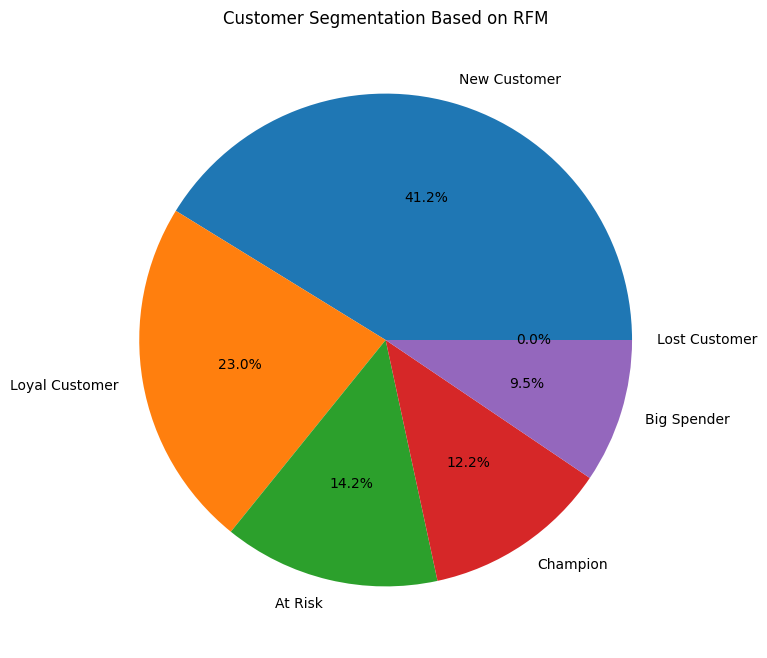

In [29]:
plt.figure(figsize=(8,8))

plt.pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%'
)

plt.title('Customer Segmentation Based on RFM')

plt.show()

RETENTION ANALYSIS

In [30]:
df['Date'] = pd.to_datetime(df['Date'])

In [31]:
df['Month'] = df['Date'].dt.to_period('M')

In [32]:
monthly_customer = df.groupby('Month')['Customer ID'].nunique()

In [33]:
print(monthly_customer)

Month
2024-01    31
2024-02    29
2024-03    30
2024-04    25
2024-05    20
2024-06    22
2024-07    22
2024-08    16
Freq: M, Name: Customer ID, dtype: int64


In [34]:
customer_month = df.groupby('Month')['Customer ID'].apply(set)

In [35]:
month = list(customer_month.index)

retention_data = []

for i in range(len(month)-1):
  current_month = month[i]
  next_month = month[i + 1]

  current_customers = customer_month[current_month]
  next_customers = customer_month[next_month]

  retained_customers = current_customers.intersection(next_customers)
  new_customers = next_customers - current_customers

  retained = current_customers.intersection(next_customers)

  retention_rate = (
      len(retained) / len(current_customers)
  ) * 100

  retention_data.append({
      'Month': str(current_month),
      'Retention Rate': retention_rate
  })

In [36]:
retention_df = pd.DataFrame(retention_data)

In [37]:
print(retention_df)

     Month  Retention Rate
0  2024-01       61.290323
1  2024-02       31.034483
2  2024-03       26.666667
3  2024-04       20.000000
4  2024-05       20.000000
5  2024-06        0.000000
6  2024-07        9.090909


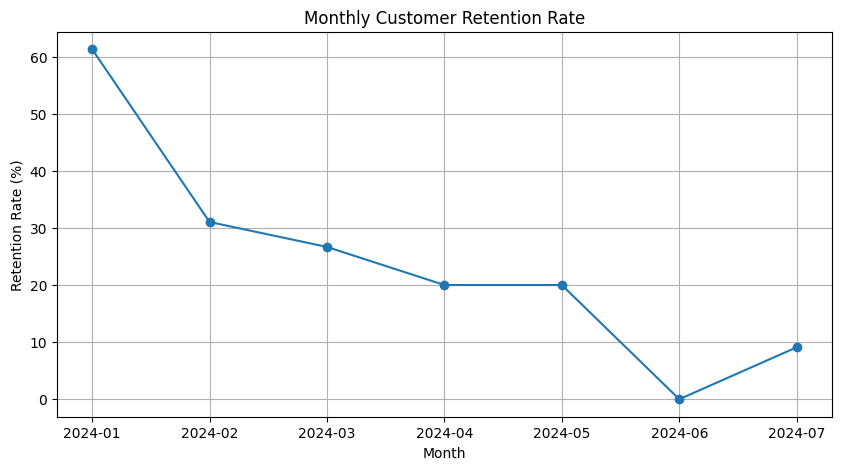

In [38]:
plt.figure(figsize=(10,5))
plt.plot(
    retention_df['Month'],
    retention_df['Retention Rate'],
    marker='o',
)
plt.title('Monthly Customer Retention Rate')

plt.xlabel('Month')
plt.ylabel('Retention Rate (%)')

plt.grid(True)
plt.show()

CHURN ANALYSIS

In [39]:
churn_days = 365

In [40]:
rfm['Churn_Status'] = np.where(
    rfm['Recency'] > churn_days,
    'Churn',
    'Active'
)

In [41]:
print(rfm[['Recency', 'Churn_Status']])

             Recency Churn_Status
Customer ID                      
C997380          724        Churn
C274870          726        Churn
C256730          628        Churn
C298229          636        Churn
C300786          757        Churn
...              ...          ...
C311034          667        Churn
C584141          666        Churn
C581947          643        Churn
C139568          669        Churn
C161285          661        Churn

[148 rows x 2 columns]


In [42]:
print(rfm['Churn_Status'].value_counts())

Churn_Status
Churn    148
Name: count, dtype: int64


In [43]:
churn_rate = (
    (rfm['Churn_Status'] == 'Churn').sum()
    / len(rfm)
)

In [44]:
print(f'Churn Rate: {churn_rate:.2f}%')

Churn Rate: 1.00%


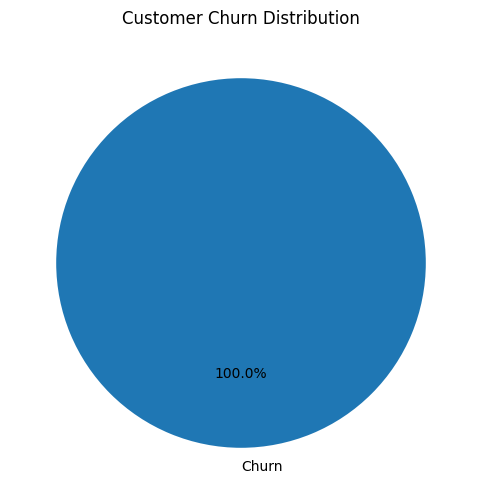

In [45]:
churn_counts = rfm['Churn_Status'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=90
)

plt.title('Customer Churn Distribution')

plt.show()

In [46]:
rfm.groupby('Churn_Status')['Monetary'].mean()

,Monetary
Churn_Status,
Churn,544.377365


In [47]:
rfm.groupby('Churn_Status')['Frequency'].mean()

,Frequency
Churn_Status,
Churn,1.621622


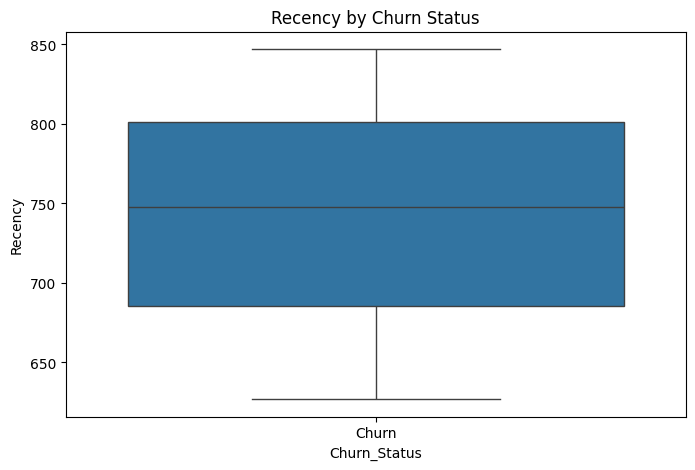

In [49]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x='Churn_Status',
    y='Recency',
    data=rfm
)

plt.title('Recency by Churn Status')

plt.show()